# 1. Overview

This notebook demonstrates the relation classifier guidance applied to different diffusion models:

- **Flux Schnell**: Ultra-fast 4-step inference, good for quick generation
- **Flux Dev**: Higher quality 50-step inference with 32×32 attention map resolution  
- **SD 2.1**: Stable Diffusion 2.1 with 50 steps at 512×512 resolution
- **SD 1.4**: Stable Diffusion 1.4 with 50 steps at 512×512 resolution

All models use the same relation classifier trained on GQA and ORM datasets to guide generation toward the specified spatial relation ("dog to the right of teddy bear"). The cross-attention maps visualize how each model learns to distribute attention across the prompt tokens during the generation process.

# 2. Setup and Imports

In [1]:
import os
import sys
from IPython.display import display
from PIL import Image
import gc
import torch
from run import generate_image_main

In [2]:
PROMPT = "a photo of a dog to the right of a teddy bear"
GPU_IDX = 7
OUTPUT_DIR = "./output"
class Args:
    def __init__(self, diffusion_version, visualize_cross_attn_maps=False, prompt="", relation_classifier_model_path=""):
        self.diffusion_version = diffusion_version
        if len(relation_classifier_model_path) == 0:
            raise ValueError("Please provide a path to the relation classifier model checkpoint.")
        
        self.relation_classifier_model_path = relation_classifier_model_path
        self.visualize_cross_attn_maps = visualize_cross_attn_maps
        self.gpu_idx = GPU_IDX
        self.output_dir = OUTPUT_DIR
        self.prompt = PROMPT if len(prompt) == 0 else prompt
        self.map_size = 16

# 3. Generate Images with Spatial Relation Guidance

## FLUX.1-schnell

Using diffusion model: schnell --> black-forest-labs/FLUX.1-schnell


/cortex/users/sapiry7/miniconda3/envs/learn_to_steer_env/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

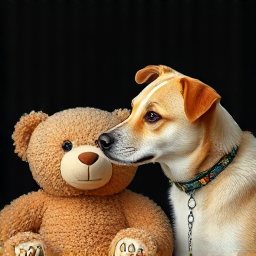

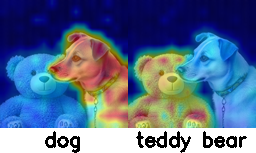

In [3]:
args = Args("schnell", visualize_cross_attn_maps=True, 
            relation_classifier_model_path="./checkpoints/flux_schnell.pth")
img_generator = generate_image_main(args)

output_path = img_generator.pipe.conf.workspace_path
output_img_path = os.path.join(output_path, f"generated_image.png")
cross_attn_img_path = os.path.join(output_path, "CA_VISUAL_TEXT/overall/", f"color__CA.png")
display(Image.open(output_img_path))
display(Image.open(cross_attn_img_path))

del img_generator
gc.collect()
torch.cuda.empty_cache()

## FLUX.1-dev

Using diffusion model: dev --> black-forest-labs/FLUX.1-dev


/cortex/users/sapiry7/miniconda3/envs/learn_to_steer_env/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

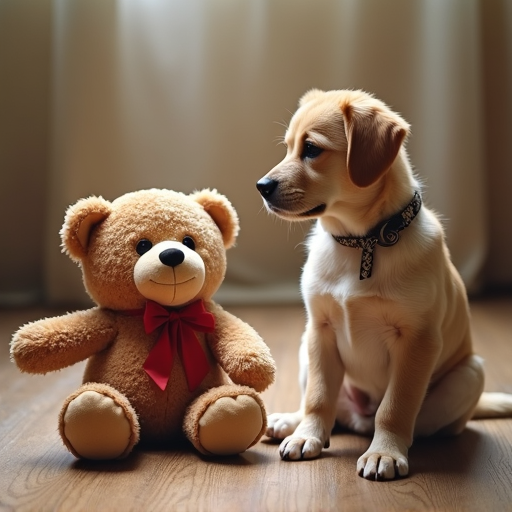

In [4]:
args = Args("dev", relation_classifier_model_path="./checkpoints/flux_dev.pth")
img_generator = generate_image_main(args)
output_img_path = os.path.join(img_generator.pipe.conf.workspace_path, f"generated_image.png")
display(Image.open(output_img_path))

del img_generator
gc.collect()
torch.cuda.empty_cache()

## Stable Diffusion 2.1-base

Using diffusion model: sd2 --> stabilityai/stable-diffusion-2-1-base


Couldn't connect to the Hub: 404 Client Error. (Request ID: Root=1-69ae9948-308a0d704e59bcb922bfb77d;9ddd2d7e-1a84-45d0-af49-1973bb111747)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1-base.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated..
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

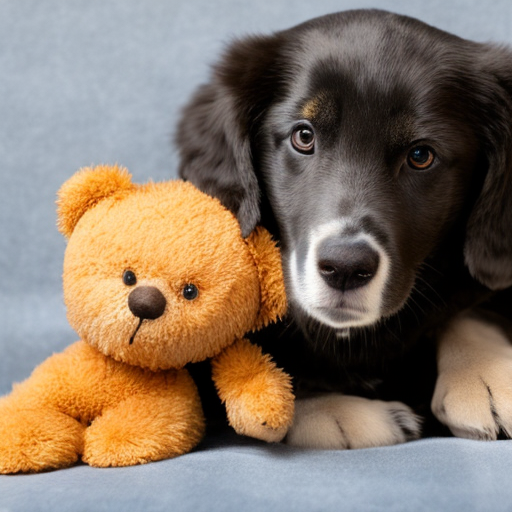

In [5]:
args = Args("sd2", relation_classifier_model_path="./checkpoints/sd2.pth")
img_generator = generate_image_main(args)
output_img_path = os.path.join(img_generator.pipe.conf.workspace_path, f"generated_image.png")
display(Image.open(output_img_path))

del img_generator
gc.collect()
torch.cuda.empty_cache()

## Stable Diffusion 1.4

Using diffusion model: sd14 --> CompVis/stable-diffusion-v1-4


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'pipelines.sd.pipeline_sd2_debug.Sd2PipelineDebug'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


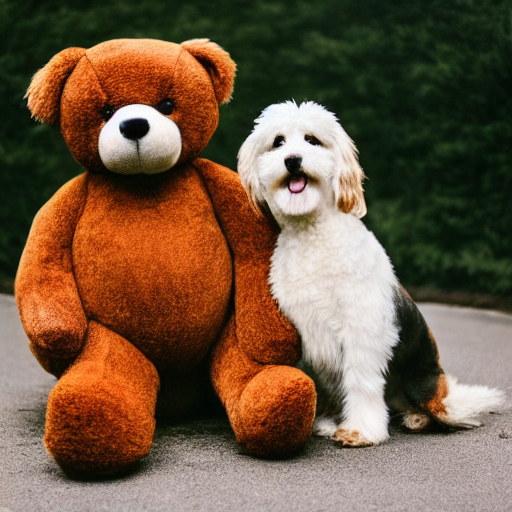

In [6]:
args = Args("sd14", relation_classifier_model_path="./checkpoints/sd14.pth")
img_generator = generate_image_main(args)
output_img_path = os.path.join(img_generator.pipe.conf.workspace_path, f"generated_image.png")
display(Image.open(output_img_path))

del img_generator
gc.collect()
torch.cuda.empty_cache()

## FLUX.1-schnell: Diagonals

Using diffusion model: schnell --> black-forest-labs/FLUX.1-schnell


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

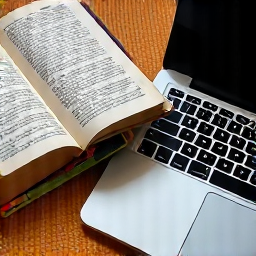

In [7]:
relation_classifier_model_path = "./checkpoints/flux_schnell_diagonals.pth"
prompt = "a photo of a book above-left of a laptop"
args = Args(
    "schnell", 
    prompt=prompt,
    relation_classifier_model_path=relation_classifier_model_path
)
img_generator = generate_image_main(args)
output_path = img_generator.pipe.conf.workspace_path
output_img_path = os.path.join(output_path, f"generated_image.png")
display(Image.open(output_img_path))

del img_generator
gc.collect()
torch.cuda.empty_cache()

## FLUX.1-dev: Multiple Relations

Using diffusion model: dev --> black-forest-labs/FLUX.1-dev


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

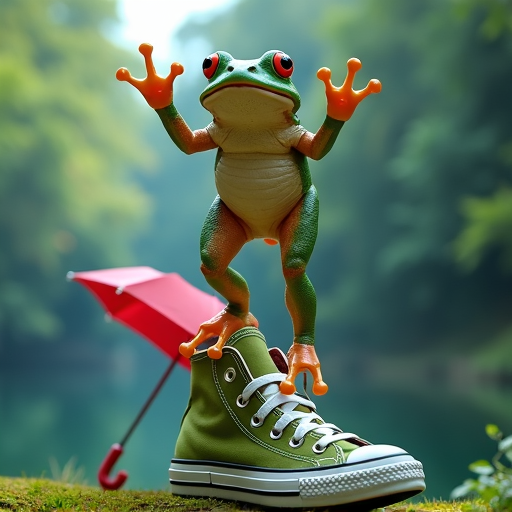

In [9]:
prompt = "a photo of a frog above a sneakers to the right of a umbrella"
args = Args("dev", prompt=prompt, relation_classifier_model_path="./checkpoints/flux_dev.pth")
img_generator = generate_image_main(args)
output_img_path = os.path.join(img_generator.pipe.conf.workspace_path, f"generated_image.png")
display(Image.open(output_img_path))

del img_generator
gc.collect()
torch.cuda.empty_cache()